In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For random forest regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

from scipy.stats import pearsonr
from scipy.sparse import issparse, vstack

# PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import sys
sys.path.append("/nfs/home/aoku/software/miniconda3/lib/python3.11/site-packages")

In [4]:
# Read scVI latent variables
scvi_latent_czi_pseudobulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_embed_train_set.csv", index_col=0)
scvi_latent_czi_pseudobulk_test = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data//scVI_embed_test_set.csv", index_col=0)

In [5]:
# Read geneformer latent variables
gf_latent_czi_pseudobulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train/gf_pseudobulk_train_set.csv", index_col=0)
gf_latent_czi_pseudobulk_test = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/gf_pseudobulk_test_set.csv", index_col=0)
gf_latent_czi_pseudobulk_test.reset_index(inplace=True, drop=True)

In [6]:
# Read cell type proportions (should be the same for both scVi and geneformer)
test_czi_cell_prop = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test_pseudobulk_cell_prop.csv")
pseudobulk_czi_cell_prop = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train_pseudobulk_cell_prop.csv")

In [7]:
def plot_true_vs_predicted(y_test_df, predicted_proportions, n_cols=4, figsize_per_plot=(3, 3), dot_size=5):

    # Get column names (cell types or lineages)
    cols = predicted_proportions.columns
    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * figsize_per_plot[0], n_rows * figsize_per_plot[1]))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        x = y_test_df[col]
        y = predicted_proportions[col]

        # Scatterplot
        sns.scatterplot(x=x, y=y, alpha=0.7, ax=ax, s=dot_size)

        # Identity line
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--')

        # Correlation coefficient
        corr, _ = pearsonr(x, y)
        ax.text(
            0.05, 0.95, f"r = {corr:.2f}",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
        )

        # Titles and labels
        ax.set_title(f'{col}')
        ax.set_xlabel('True')
        ax.set_ylabel('Predicted')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# scVI

In [110]:
# Split into train and test sets
X = scvi_latent_czi_pseudobulk
y = pseudobulk_czi_cell_prop

# Split data into training and test splits
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [27]:
# Define base model
rf = RandomForestRegressor(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Grid Search with 5-fold CV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    verbose=1
)

# Fit to training data
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Use the best model
best_rf = grid_search.best_estimator_

# Predict on test data
y_pred = best_rf.predict(X_test)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/nfs/sw/easybuild/software/custom-conda/geneformer-1.0/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
540 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
301 fits failed with the following error:
Traceback (most recent call last):
  File "/nfs/sw/easybuild/software/custom-conda/geneformer-1.0/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/nfs/sw/easybuild/software/custom-conda/geneformer-1.0/lib/python3.10/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/nfs/sw/easybuild/software/custom-conda/geneformer-

Best parameters found:  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


In [111]:
model_rf_scvi = RandomForestRegressor(max_depth=20, max_features="sqrt", min_samples_leaf = 1, min_samples_split = 2, n_estimators=500, random_state=42)
model_rf_scvi.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, max_features='sqrt', n_estimators=500,
                      random_state=42)

In [112]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model_rf_scvi.predict(X_test)

# Convert to DataFrame
predicted_proportions = pd.DataFrame(y_pred, columns=y_test.columns, index=X_test.index)

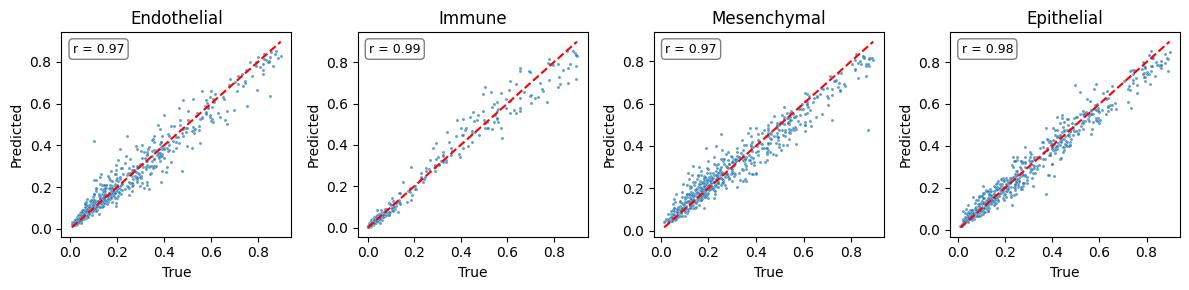

In [113]:
# Plot correlations (pearson)
plot_true_vs_predicted(y_test,predicted_proportions)

In [114]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model_rf_scvi.predict(scvi_latent_czi_pseudobulk_test)

# Convert to DataFrame
predicted_proportions_test = pd.DataFrame(y_pred, columns=y_train.columns, index=latent_czi_pseudobulk_test.index)

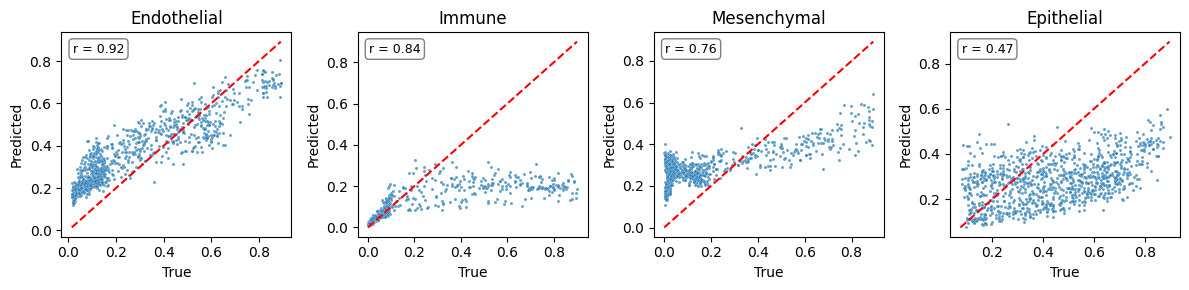

In [115]:
# Plot correlations (pearson)
plot_true_vs_predicted(test_czi_cell_prop,predicted_proportions_test)

# Geneformer

In [50]:
# Split into train and test sets
X = gf_latent_czi_pseudobulk
y = pseudobulk_czi_cell_prop

# Split data into training and test splits
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [40]:
# Define base model
rf = RandomForestRegressor(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Grid Search with 5-fold CV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    verbose=1
)

# Fit to training data
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Use the best model
best_rf = grid_search.best_estimator_

# Predict on test data
y_pred = best_rf.predict(X_test)

In [51]:
model_rf_gf = RandomForestRegressor(max_depth=None, max_features="sqrt", min_samples_leaf = 1, min_samples_split = 2, n_estimators=500, random_state=42)
model_rf_gf.fit(X_train, y_train)

RandomForestRegressor(max_features='sqrt', n_estimators=500, random_state=42)

In [52]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model_rf_gf.predict(X_test)

# Convert to DataFrame
predicted_proportions = pd.DataFrame(y_pred, columns=y_test.columns, index=X_test.index)

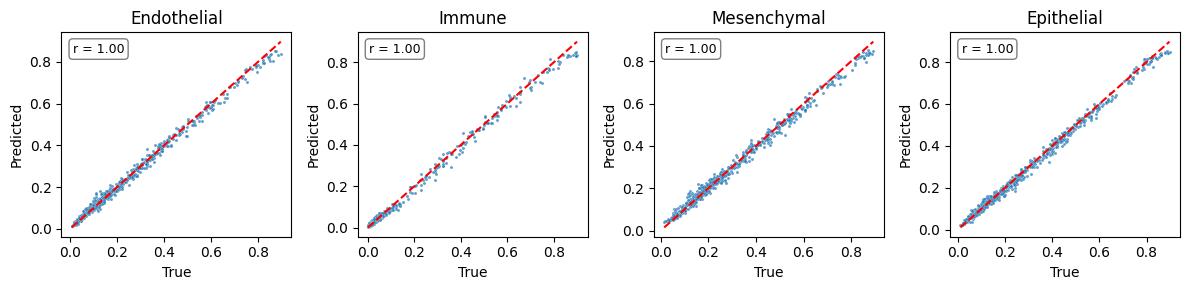

In [53]:
# Plot correlations (pearson)
plot_true_vs_predicted(y_test,predicted_proportions)

In [54]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model_rf_gf.predict(gf_latent_czi_pseudobulk_test)

# Convert to DataFrame
predicted_proportions_test = pd.DataFrame(y_pred, columns=y_train.columns, index=gf_latent_czi_pseudobulk_test.index)

In [55]:
gf_latent_czi_pseudobulk_test.shape

(1000, 1152)

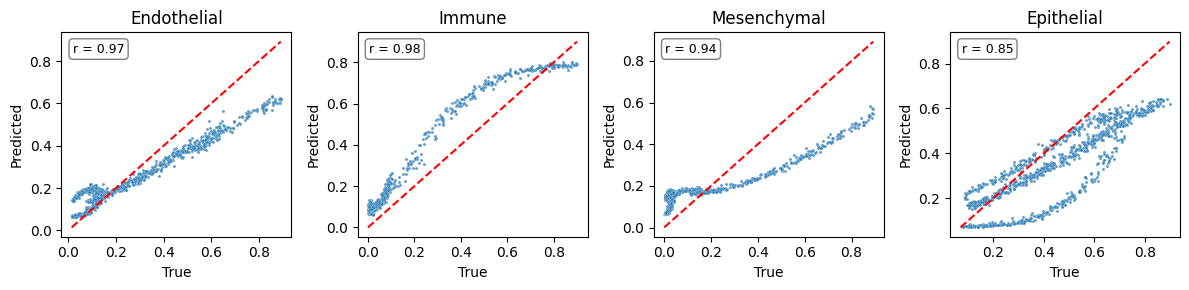

In [56]:
# Plot correlations (pearson)
plot_true_vs_predicted(test_czi_cell_prop,predicted_proportions_test)

In [57]:
predicted_proportions_test.columns

Index(['Endothelial', 'Immune', 'Mesenchymal', 'Epithelial'], dtype='object')

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Mean Absolute Error
mae = mean_absolute_error(test_czi_cell_prop[predicted_proportions_test.columns], predicted_proportions_test)

# Mean Squared Error
mse = mean_squared_error(test_czi_cell_prop[predicted_proportions_test.columns], predicted_proportions_test)

# Root Mean Squared Error
rmse = np.sqrt(mse)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE : 0.1022
MSE : 0.0156
RMSE: 0.1247


     Cell_Type       MAE       MSE      RMSE
0  Endothelial  0.079623  0.010445  0.102203
1       Immune  0.092195  0.010287  0.101427
2  Mesenchymal  0.117298  0.019262  0.138786
3   Epithelial  0.119732  0.022206  0.149016


/tmp/ipykernel_190617/126932526.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df["Cell_Type"], rotation=45, ha="right")
/tmp/ipykernel_190617/126932526.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df["Cell_Type"], rotation=45, ha="right")
/tmp/ipykernel_190617/126932526.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df["Cell_Type"], rotation=45, ha="right")


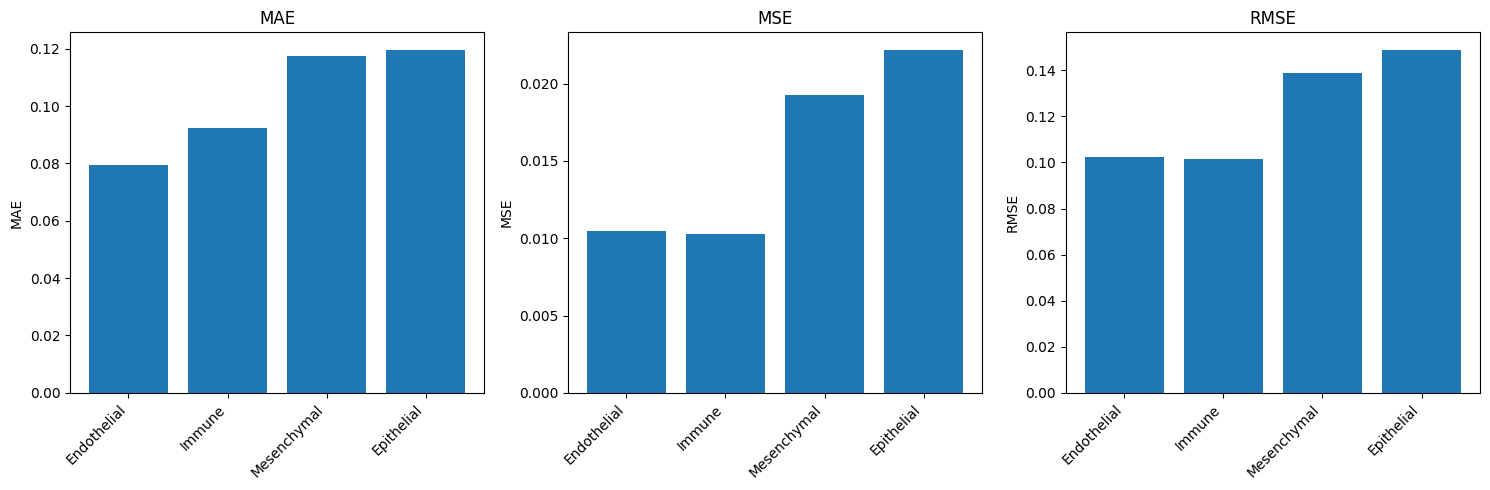

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Store results per column
results = []
for col in predicted_proportions_test.columns:
    y_true = test_czi_cell_prop[col]
    y_pred = predicted_proportions_test[col]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    results.append({"Cell_Type": col, "MAE": mae, "MSE": mse, "RMSE": rmse})

# Convert to DataFrame for easy plotting
results_df = pd.DataFrame(results)
print(results_df)

### Try scaling - Geneformer

In [31]:
# #Define standard scaler
# scaler = StandardScaler()

# # Scale train set
# gf_latent_czi_pseudobulk_z = pd.DataFrame(
#     scaler.fit_transform(gf_latent_czi_pseudobulk),
#     index=gf_latent_czi_pseudobulk.index,
#     columns=gf_latent_czi_pseudobulk.columns
# )

# # scale test set
# gf_latent_czi_pseudobulk_test_z = pd.DataFrame(
#     scaler.fit_transform(gf_latent_czi_pseudobulk_test),
#     index=gf_latent_czi_pseudobulk_test.index,
#     columns=gf_latent_czi_pseudobulk_test.columns
# )

# # Define X and y 
# X = gf_latent_czi_pseudobulk_z
# y = pseudobulk_czi_cell_prop.loc[gf_latent_czi_pseudobulk_z.index, :]

In [32]:
# Split into train and test sets
X = gf_latent_czi_pseudobulk
y = pseudobulk_czi_cell_prop

# Split data into training and test splits
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)  # Compute mean and std from training data
X_train_scaled = scaler.transform(X_train)

In [99]:
X_test_scaled = pd.DataFrame(scaler.transform(X_test))

In [100]:
X_test_scaled.head()

,0,1,2,3,4,5,6,7,8,9,...,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151
0,1.301046,1.947780,1.190660,0.917503,1.016249,-2.385553,0.449957,-1.222566,-0.553732,0.772550,...,0.588886,-1.044397,-0.137707,0.010702,-1.264161,0.815269,-2.001226,1.302888,-1.573281,0.889651
1,1.002106,0.718474,0.777655,-0.537306,1.314862,-0.100641,1.287283,-1.425336,-0.975346,-0.415128,...,1.370964,-1.764610,-1.126461,0.502820,-0.450266,0.651691,0.182475,0.016743,-0.611199,0.676688
2,0.952425,-0.014069,0.677856,-0.397748,1.349002,-1.930189,1.143814,-1.435529,-0.808727,0.429138,...,0.598741,-1.349328,-0.025444,-0.035960,-0.004564,0.528766,-0.615882,-0.188437,-1.618468,1.036303
3,1.666460,-1.509868,0.428716,0.930428,0.690091,0.823298,0.757166,0.389104,1.611552,1.734814,...,-1.533072,0.418556,0.390832,-1.522045,-0.537721,1.433007,-0.905590,-1.572679,0.133708,-1.859456
4,-0.947581,-1.184853,-0.432054,-1.135347,0.765891,0.607758,-0.788961,-0.504294,-0.895599,-0.608495,...,1.182486,0.721572,0.298033,-0.011410,0.990490,-0.978316,1.808375,-0.544235,-0.221894,0.788047


In [101]:
X_test.head()

,0,1,2,3,4,5,6,7,8,9,...,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151
1801,-0.045845,-0.083647,0.012752,0.049052,0.012789,-0.062717,0.025600,-0.060085,-0.352346,-0.198200,...,-0.013510,0.011828,0.003966,0.015929,-0.029179,-0.045409,0.063701,-0.000473,-0.031150,0.042036
1190,-0.047075,-0.085993,0.011097,0.040730,0.014875,-0.046454,0.030578,-0.062793,-0.360537,-0.203628,...,-0.010128,0.001146,0.001489,0.020865,-0.025511,-0.046340,0.069383,-0.006714,-0.021800,0.039454
1817,-0.047279,-0.087392,0.010697,0.041528,0.015113,-0.059476,0.029725,-0.062929,-0.357300,-0.199769,...,-0.013468,0.007305,0.004247,0.015461,-0.023502,-0.047039,0.067306,-0.007709,-0.031589,0.043813
251,-0.044342,-0.090247,0.009698,0.049126,0.010510,-0.039878,0.027426,-0.038561,-0.310279,-0.193803,...,-0.022689,0.033526,0.005290,0.000554,-0.025905,-0.041894,0.066552,-0.014426,-0.014560,0.008713
2505,-0.055092,-0.089627,0.006247,0.037309,0.011040,-0.041412,0.018234,-0.050492,-0.358988,-0.204511,...,-0.010943,0.038020,0.005057,0.015707,-0.019017,-0.055615,0.073613,-0.009436,-0.018016,0.040804


In [102]:
model_rf_gf = RandomForestRegressor(max_depth=None, max_features="sqrt", min_samples_leaf = 1, min_samples_split = 2, n_estimators=500, random_state=42)
model_rf_gf.fit(X_train_scaled, y_train)

RandomForestRegressor(max_features='sqrt', n_estimators=500, random_state=42)

In [103]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model_rf_gf.predict(X_test_scaled)

# Convert to DataFrame
predicted_proportions = pd.DataFrame(y_pred, columns=y_test.columns, index=X_test.index)

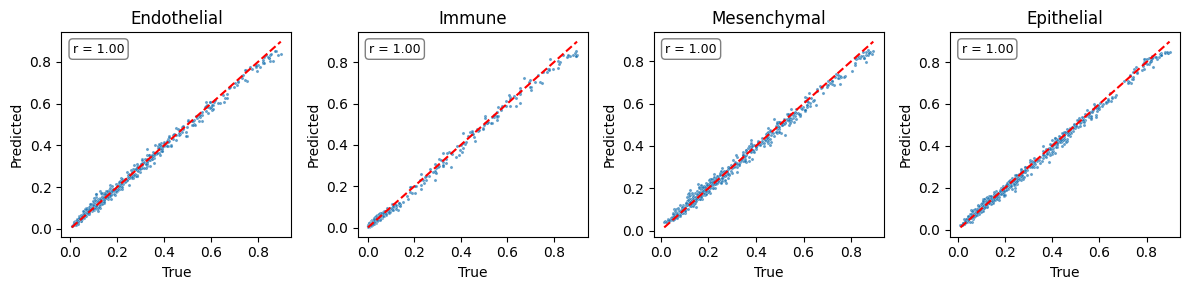

In [104]:
# Plot correlations (pearson)
plot_true_vs_predicted(y_test,predicted_proportions)

In [108]:
# transform using scaling fit on training data
gf_latent_czi_pseudobulk_test_scaled = pd.DataFrame(scaler.transform(gf_latent_czi_pseudobulk_test))

In [110]:
gf_latent_czi_pseudobulk_test_scaled.head()

,0,1,2,3,4,5,6,7,8,9,...,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151
0,-2.526362,0.836949,1.750274,0.360030,-1.889937,0.313032,-0.811148,0.662845,0.790850,0.171874,...,-0.508237,0.357730,1.439892,0.688822,-1.329634,0.654558,-0.267130,-0.193171,1.046735,-1.021160
1,-1.302585,0.665658,2.241677,-1.627249,-2.797295,0.172274,-1.893529,0.872406,1.735753,0.101932,...,-0.767908,0.598474,2.057770,-0.030594,1.253673,1.627642,1.045844,0.552172,1.442695,-1.411823
2,-3.369957,-1.730073,1.552596,0.239301,-0.896872,2.799050,1.310941,0.320086,0.656119,-0.655067,...,-1.945409,-1.423340,2.993889,0.754017,-0.541752,-0.594683,0.747158,-0.464028,1.143187,-0.301555
3,-1.742558,-0.968601,-0.884298,2.083280,-3.854272,1.613302,0.122128,2.282261,-0.095865,0.435952,...,-1.092548,0.440157,2.014148,1.093863,0.678939,-0.828749,-3.822057,1.349139,0.381198,-0.931011
4,-1.893353,0.487630,1.504237,0.209524,-2.017381,0.560799,-0.723118,1.003480,0.613544,-0.042382,...,-0.764615,0.219711,0.504821,0.771184,-1.149332,0.351524,0.010094,-0.361456,1.269141,-0.968366


In [111]:
gf_latent_czi_pseudobulk_test.head()

,0,1,2,3,4,5,6,7,8,9,...,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151
0,-0.061585,-0.085767,0.014996,0.045863,-0.007513,-0.043510,0.018102,-0.034905,-0.326224,-0.200945,...,-0.018256,0.032624,0.007917,0.022731,-0.029474,-0.046323,0.068213,-0.007732,-0.005687,0.018874
1,-0.056552,-0.086094,0.016966,0.034495,-0.013851,-0.044512,0.011667,-0.032106,-0.307866,-0.201265,...,-0.019379,0.036194,0.009465,0.015515,-0.017831,-0.040786,0.071629,-0.004115,-0.001838,0.014139
2,-0.065054,-0.090668,0.014203,0.045172,-0.000576,-0.025816,0.030718,-0.039482,-0.328841,-0.204724,...,-0.024472,0.006207,0.011810,0.023385,-0.025923,-0.053432,0.070852,-0.009047,-0.004749,0.027597
3,-0.058362,-0.089214,0.004434,0.055720,-0.021235,-0.034256,0.023651,-0.013277,-0.343451,-0.199738,...,-0.020783,0.033846,0.009356,0.026794,-0.020422,-0.054764,0.058964,-0.000248,-0.012155,0.019967
4,-0.058982,-0.086434,0.014009,0.045002,-0.008403,-0.041747,0.018625,-0.030356,-0.329668,-0.201924,...,-0.019365,0.030576,0.005575,0.023557,-0.028661,-0.048048,0.068934,-0.008549,-0.003525,0.019514


In [112]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model_rf_gf.predict(gf_latent_czi_pseudobulk_test_scaled)

# Convert to DataFrame
predicted_proportions_test = pd.DataFrame(y_pred, columns=y_train.columns, index=gf_latent_czi_pseudobulk_test.index)

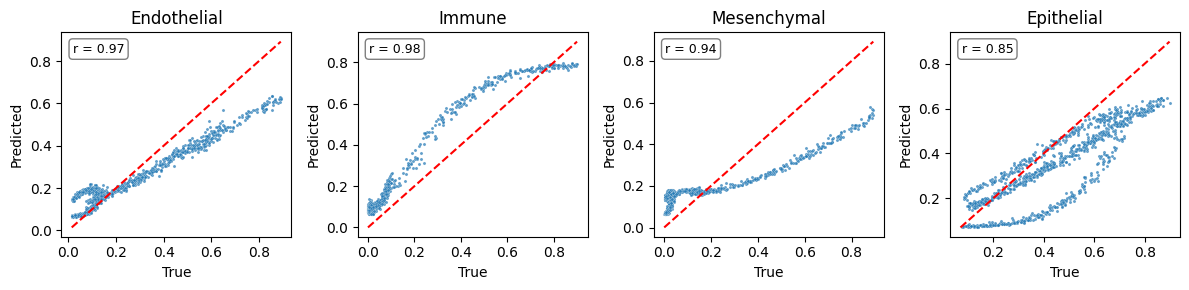

In [113]:
# Plot correlations (pearson)
plot_true_vs_predicted(test_czi_cell_prop,predicted_proportions_test)

# PCA

In [68]:
# Read in pseudbulks transform using PCA
train_pseudobulk_czi = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/pseudobulk_train_set.csv", index_col=0)
test_pseudobulk_czi = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/pseudobulk_test_set.csv")

In [69]:
test_pseudobulk_czi.head()

,ENSG00000243485,ENSG00000237613,ENSG00000186092,ENSG00000238009,ENSG00000239945,ENSG00000239906,ENSG00000241860,ENSG00000241599,ENSG00000286448,ENSG00000236601,...,ENSG00000274175,ENSG00000275869,ENSG00000273554,ENSG00000278782,ENSG00000277761,ENSG00000277836,ENSG00000278633,ENSG00000276017,ENSG00000278817,ENSG00000277196
0,0.0,0.0,1.0,9.0,0.0,0.0,11.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,6.0,0.0,0.0,11.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
2,0.0,0.0,0.0,4.0,0.0,0.0,21.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,1.0,0.0
3,0.0,0.0,0.0,31.0,0.0,0.0,9.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,8.0,0.0,0.0,8.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0


In [70]:
print(train_pseudobulk_czi.shape)
print(test_pseudobulk_czi.shape)

(3000, 36592)
(1000, 36592)


In [71]:
train_test_merged = pd.concat([train_pseudobulk_czi, test_pseudobulk_czi], ignore_index=True)

In [72]:
train_test_merged.shape

(4000, 36592)

In [74]:
# Standardize the data
scaler = StandardScaler()
train_test_merged = scaler.fit_transform(train_test_merged)

# Run PCA
pca = PCA(n_components=100) 
pca_merged = pca.fit_transform(train_test_merged)

In [75]:
# transform to dataframe
pca_merged = pd.DataFrame(pca_merged)

In [76]:
# Split into train and test sets
X = pca_merged.iloc[0:3000, :]
y = pseudobulk_czi_cell_prop

# Split data into training and test splits
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [ ]:
# Define base model
rf = RandomForestRegressor(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Grid Search with 5-fold CV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    verbose=1
)

# Fit to training data
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Use the best model
best_rf = grid_search.best_estimator_

# Predict on test data
y_pred = best_rf.predict(X_test)

In [77]:
model_rf_pca = RandomForestRegressor(max_depth=30, max_features="sqrt", min_samples_leaf = 1, min_samples_split = 2, n_estimators=500, random_state=42)
model_rf_pca.fit(X_train, y_train)

RandomForestRegressor(max_depth=30, max_features='sqrt', n_estimators=500,
                      random_state=42)

In [78]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model_rf_pca.predict(X_test)

# Convert to DataFrame
predicted_proportions = pd.DataFrame(y_pred, columns=y_test.columns, index=X_test.index)

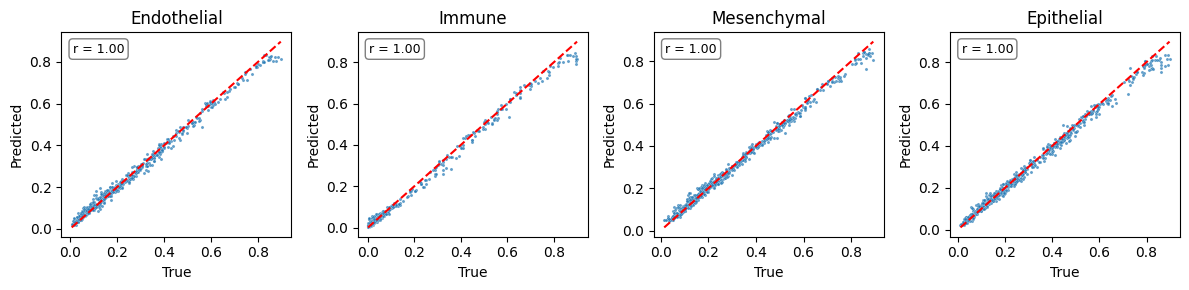

In [79]:
# Plot correlations (pearson)
plot_true_vs_predicted(y_test,predicted_proportions)

In [80]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model_rf_pca.predict(pca_merged.iloc[3000:, ])

# Convert to DataFrame
predicted_proportions_test = pd.DataFrame(y_pred, columns=y_train.columns)

In [81]:
predicted_proportions_test.head()

,Endothelial,Immune,Mesenchymal,Epithelial
0,0.241655,0.136850,0.327682,0.293813
1,0.258180,0.166187,0.304860,0.270773
2,0.241008,0.177940,0.258065,0.322987
3,0.284973,0.213830,0.276632,0.224565
4,0.305675,0.121750,0.286295,0.286280


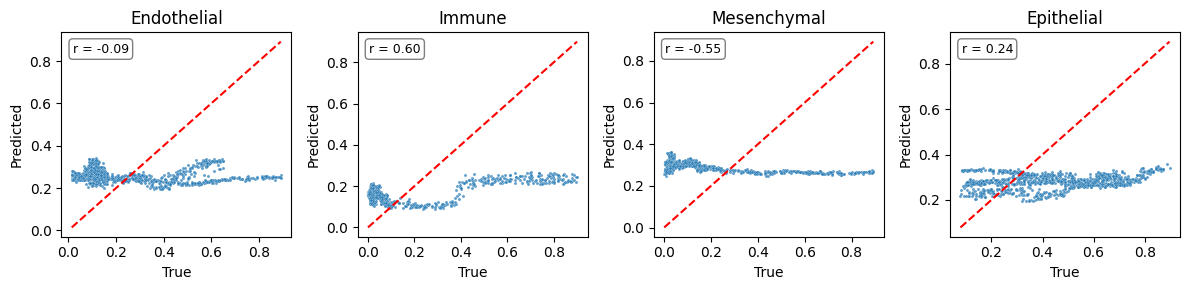

In [82]:
# Plot correlations (pearson)
plot_true_vs_predicted(test_czi_cell_prop.iloc[0:1000,],predicted_proportions_test)

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Mean Absolute Error
mae = mean_absolute_error(test_czi_cell_prop[predicted_proportions_test.columns], predicted_proportions_test)

# Mean Squared Error
mse = mean_squared_error(test_czi_cell_prop[predicted_proportions_test.columns], predicted_proportions_test)

# Root Mean Squared Error
rmse = np.sqrt(mse)

print(f"MAE : {mae:.3f}")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE : 0.212
MSE : 0.062
RMSE: 0.248


In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Store results per column
results = []
for col in predicted_proportions_test.columns:
    y_true = test_czi_cell_prop[col]
    y_pred = predicted_proportions_test[col]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    results.append({"Cell_Type": col, "MAE": mae, "MSE": mse, "RMSE": rmse})

# Convert to DataFrame for easy plotting
results_df = pd.DataFrame(results)
print(results_df)

     Cell_Type       MAE       MSE      RMSE
0  Endothelial  0.203665  0.056555  0.237812
1       Immune  0.179995  0.049095  0.221574
2  Mesenchymal  0.252730  0.073947  0.271932
3   Epithelial  0.213435  0.066980  0.258804


# MuSiC

In [29]:
# Read music results
music_deconv = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/outputs/music_prop_pseudobulk_czi_vs_czi_single_cell_ref_estimated_heca_lineage.csv",
                          index_col=0)

In [30]:
music_deconv = music_deconv[["Epithelial", "Endothelial", "Mesenchymal", "Immune"]]
music_deconv.reset_index(drop=True, inplace=True)

In [31]:
music_deconv.head()

,Epithelial,Endothelial,Mesenchymal,Immune
0,0.371150,0.500299,0.007632,0.120920
1,0.089849,0.894953,0.000000,0.015197
2,0.254146,0.073316,0.638458,0.034080
3,0.267567,0.005897,0.000000,0.726536
4,0.185641,0.609818,0.028036,0.176505


In [32]:
# check if sample names match
#nums = [int(s.split("_")[1]) for s in music_deconv.index]
#is_sequential = nums == list(range(min(nums), max(nums) + 1))

In [34]:
test_czi_cell_prop.head()

,Epithelial,Endothelial,Mesenchymal,Immune
0,0.40000,0.43500,0.10250,0.06250
1,0.13000,0.86000,0.00875,0.00125
2,0.25125,0.05500,0.68500,0.00875
3,0.33875,0.06500,0.01750,0.57875
4,0.22500,0.55625,0.14250,0.07625


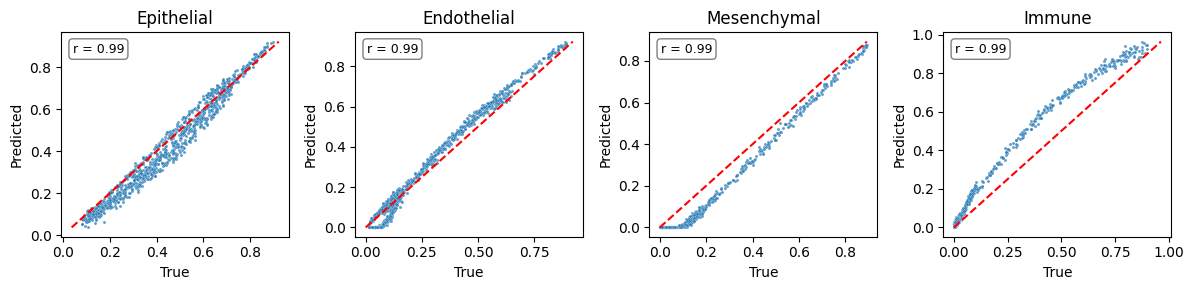

In [35]:
# Plot correlations (pearson)
plot_true_vs_predicted(test_czi_cell_prop,music_deconv)

In [128]:
# Read music results
music_deconv_train_samp = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/outputs/music_prop_pseudobulk_czi_vs_czi_single_cell_ref_estimated_heca_lineage_3_train_samples.csv",
                          index_col=0)

In [129]:
music_deconv_train_samp = music_deconv_train_samp[["Epithelial", "Endothelial", "Mesenchymal", "Immune"]]
music_deconv_train_samp.reset_index(drop=True, inplace=True)

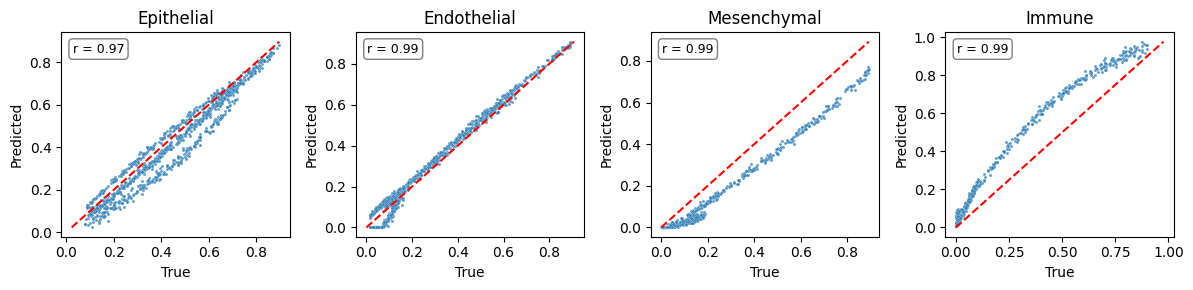

In [130]:
# Plot correlations (pearson)
plot_true_vs_predicted(test_czi_cell_prop,music_deconv_train_samp)

# Batch correct using Harmony

In [12]:
import sys
sys.path.append("/nfs/home/aoku/software/miniconda3/lib/python3.11/site-packages")

import harmonypy as hm

In [13]:
!pip show xgboost

Name: xgboost
Version: 3.0.4
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /nfs/home/aoku/software/miniconda3/lib/python3.11/site-packages
Requires: numpy, nvidia-nccl-cu12, scipy
Required-by: 


### On geneformer embeddings

In [14]:
# pca_merged.iloc[0:3000, :]
# pca_merged.iloc[3000:, ]

# gf_latent_czi_pseudobulk
# gf_latent_czi_pseudobulk_test

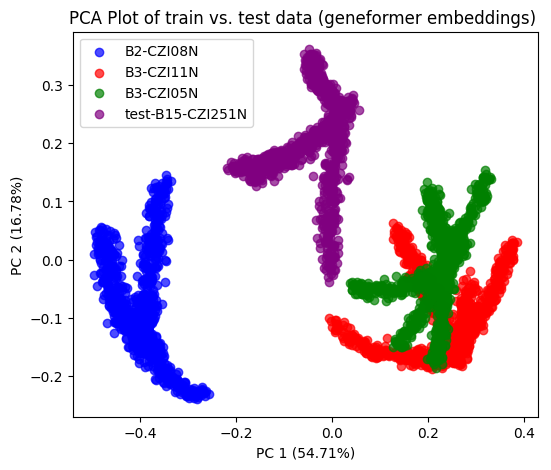

In [15]:
# Step 1: Merge the two dataframes and add a 'source' column
pseudobulk_df_with_source = gf_latent_czi_pseudobulk.copy()
pseudobulk_df_with_source['source'] = 'train'

test_df_with_source = gf_latent_czi_pseudobulk_test.copy()
test_df_with_source['source'] = 'test'

merged_df = pd.concat([pseudobulk_df_with_source, test_df_with_source], ignore_index=True)

sample_labels = ['B2-CZI08N'] * 1000 + ['B3-CZI11N'] * 1000 + ['B3-CZI05N'] * 1000 + ['test-B15-CZI251N'] * 1000
merged_df['sample'] = sample_labels

metadata_concat = pd.concat([pseudobulk_czi_cell_prop, test_czi_cell_prop])

# Step 2: Prepare data for PCA
# The source column needs to be dropped for the PCA calculation
X = merged_df.drop(['source', "sample"], axis=1)

# Step 3: Perform PCA
# We will reduce the dimensionality to 2 principal components for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Step 4: Create a new DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['sample'] = merged_df['sample']

# Step 5: Plot the PCA results
plt.figure(figsize=(6, 5))

# Get unique sources for different colors
sources = pca_df['sample'].unique()
colors = ['blue', 'red', 'green', 'purple']  # Or any other color scheme

for i, source in enumerate(sources):
    # Filter the data for each source
    subset = pca_df[pca_df['sample'] == source]
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        c=colors[i],
        label=source,
        alpha=0.7
    )

# Add labels and title
plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Plot of train vs. test data (geneformer embeddings) ')
plt.legend()
plt.grid(False)
plt.show()

In [16]:
merged_df['sample'].value_counts()

sample
B2-CZI08N           1000
B3-CZI11N           1000
B3-CZI05N           1000
test-B15-CZI251N    1000
Name: count, dtype: int64

In [17]:
# Run Harmony
vars_use = ["sample"]
ho = hm.run_harmony(merged_df.drop(['sample', 'source'], axis=1), merged_df, vars_use)

# Write the adjusted PCs to a new file.
res = pd.DataFrame(ho.Z_corr)
res = res.T
res.columns = ['{}'.format(i) for i in range(res.shape[1])]

2025-08-25 15:36:41,615 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-25 15:36:44,083 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-25 15:36:44,099 - harmonypy - INFO - Iteration 1 of 10
2025-08-25 15:36:45,373 - harmonypy - INFO - Iteration 2 of 10
2025-08-25 15:36:46,541 - harmonypy - INFO - Iteration 3 of 10
2025-08-25 15:36:47,714 - harmonypy - INFO - Converged after 3 iterations


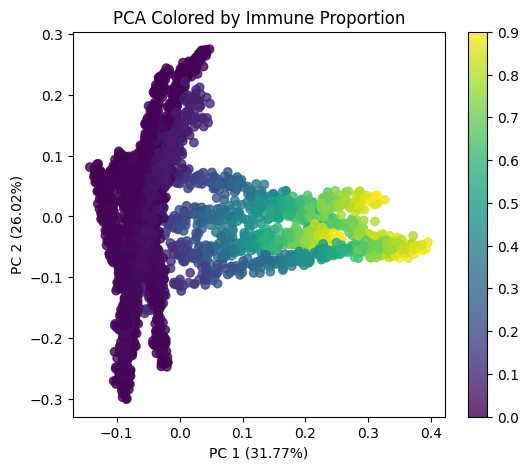

In [18]:
# merge data
merged_df_harmony = res.copy()
merged_df_harmony["source"] = merged_df["source"]

# Concatenate metadata
metadata_concat = pd.concat([pseudobulk_czi_cell_prop, test_czi_cell_prop], ignore_index=True)

# Ensure metadata index matches merged_df
metadata_concat = metadata_concat.reset_index(drop=True)

# Drop 'source' before PCA
X = merged_df_harmony.drop('source', axis=1)

# PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Create PCA DataFrame
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Add Epithelial values
pca_df['Epithelial'] = metadata_concat['Immune'].values

# Plot PCA, colored by 'Epithelial'
plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    pca_df['PC1'], 
    pca_df['PC2'], 
    c=pca_df['Epithelial'], 
    cmap='viridis', 
    alpha=0.8
)

plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Colored by Immune Proportion')
plt.colorbar(scatter, label='')
plt.grid(False)
plt.show()

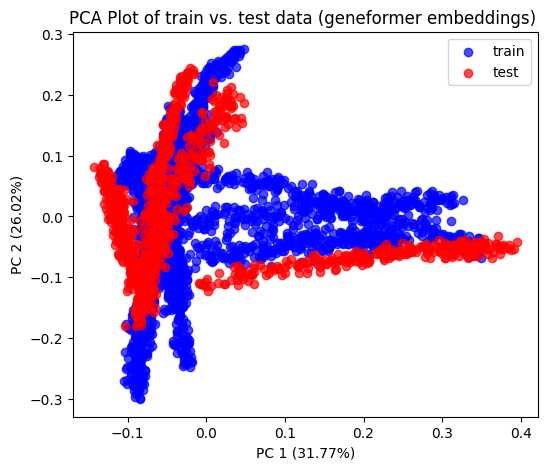

In [19]:
# merge data
merged_df_harmony = res.copy()
merged_df_harmony["source"] = merged_df["source"]

metadata_concat = pd.concat([pseudobulk_czi_cell_prop, test_czi_cell_prop])

# Step 2: Prepare data for PCA
# The source column needs to be dropped for the PCA calculation
X = merged_df_harmony.drop('source', axis=1)

# Step 3: Perform PCA
# We will reduce the dimensionality to 2 principal components for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Step 4: Create a new DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['source'] = merged_df['source']

# Step 5: Plot the PCA results
plt.figure(figsize=(6, 5))

# Get unique sources for different colors
sources = pca_df['source'].unique()
colors = ['blue', 'red', 'green']  # Or any other color scheme

for i, source in enumerate(sources):
    # Filter the data for each source
    subset = pca_df[pca_df['source'] == source]
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        c=colors[i],
        label=source,
        alpha=0.7
    )

# Add labels and title
plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Plot of train vs. test data (geneformer embeddings) ')
plt.legend()
plt.grid(False)
plt.show()

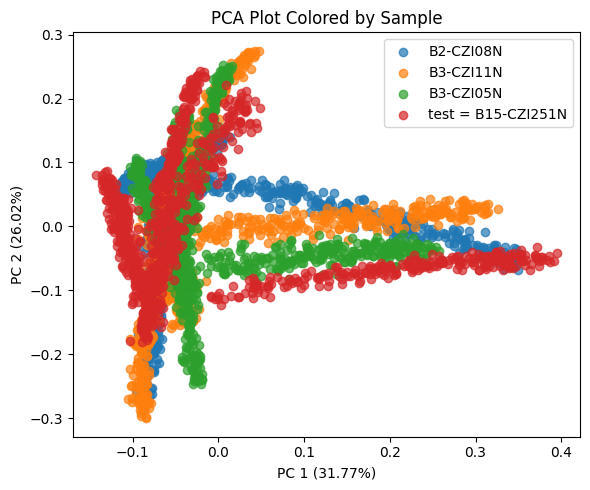

In [20]:
# merge data
merged_df_harmony = res.copy()
merged_df_harmony["source"] = merged_df["source"]

metadata_concat = pd.concat([pseudobulk_czi_cell_prop, test_czi_cell_prop])

sample_labels = ['B2-CZI08N'] * 1000 + ['B3-CZI11N'] * 1000 + ['B3-CZI05N'] * 1000 + ['test = B15-CZI251N'] * 1000
merged_df_harmony['sample'] = sample_labels

# PCA input (excluding 'source' and 'sample')
X = merged_df_harmony.drop(['source', 'sample'], axis=1)

# PCA computation
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Create plot DataFrame
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['sample'] = merged_df_harmony['sample']

# Plot
plt.figure(figsize=(6, 5))

for sample in pca_df['sample'].unique():
    subset = pca_df[pca_df['sample'] == sample]
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=sample,
        alpha=0.7
    )

plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Plot Colored by Sample')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

In [21]:
# Split into train and test sets
X = merged_df_harmony.iloc[0:3000, :-2]
y = pseudobulk_czi_cell_prop

# Split data into training and test splits
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [25]:
#merged_df_harmony.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/geneformer_harmony_train_and_test.csv")

In [22]:
# Fit  model
model_rf_gf = RandomForestRegressor(max_depth=None, max_features="sqrt", min_samples_leaf = 1, min_samples_split = 2, n_estimators=500, random_state=42)
model_rf_gf.fit(X_train, y_train)

RandomForestRegressor(max_features='sqrt', n_estimators=500, random_state=42)

In [123]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model_rf_gf.predict(X_test)

# Convert to DataFrame
predicted_proportions = pd.DataFrame(y_pred, columns=y_test.columns, index=X_test.index)

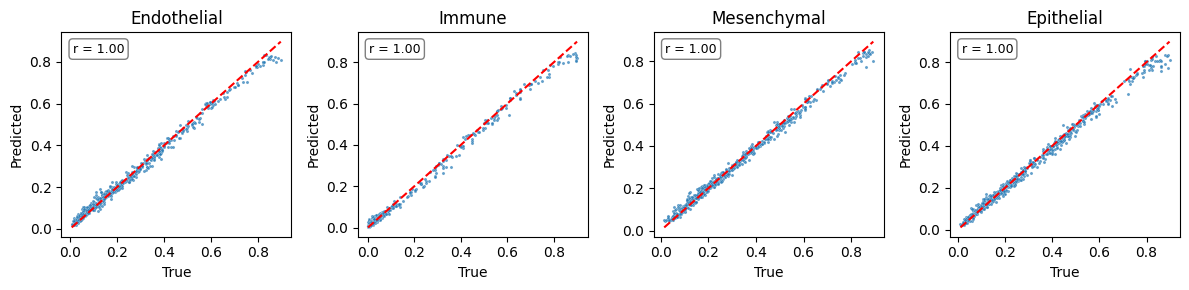

In [124]:
# Plot correlations (pearson)
plot_true_vs_predicted(y_test,predicted_proportions)

In [125]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model_rf_gf.predict(merged_df_harmony.iloc[3000:, :-2])

# Convert to DataFrame
predicted_proportions_test = pd.DataFrame(y_pred, columns=y_train.columns)

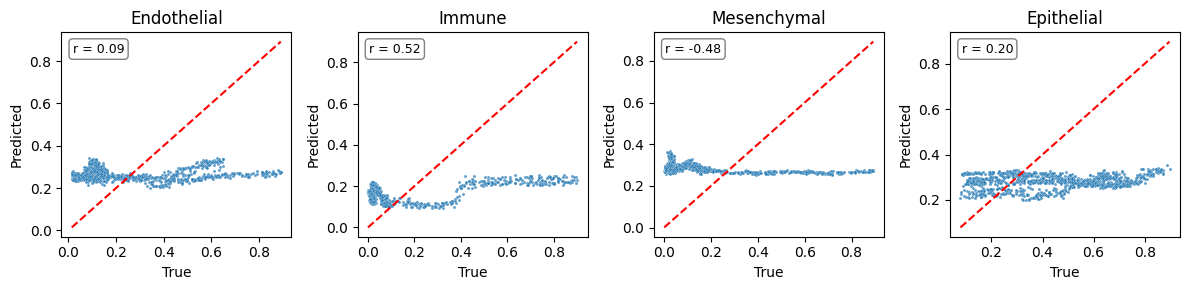

In [126]:
# Plot correlations (pearson)
plot_true_vs_predicted(test_czi_cell_prop,predicted_proportions_test)

In [127]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Mean Absolute Error
mae = mean_absolute_error(test_czi_cell_prop[predicted_proportions_test.columns], predicted_proportions_test)

# Mean Squared Error
mse = mean_squared_error(test_czi_cell_prop[predicted_proportions_test.columns], predicted_proportions_test)

# Root Mean Squared Error
rmse = np.sqrt(mse)

print(f"MAE : {mae:.3f}")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE : 0.211
MSE : 0.061
RMSE: 0.247


In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Store results per column
results = []
for col in predicted_proportions_test.columns:
    y_true = test_czi_cell_prop[col]
    y_pred = predicted_proportions_test[col]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    results.append({"Cell_Type": col, "MAE": mae, "MSE": mse, "RMSE": rmse})

# Convert to DataFrame for easy plotting
results_df = pd.DataFrame(results)
print(results_df)

     Cell_Type       MAE       MSE      RMSE
0  Endothelial  0.201075  0.054049  0.232485
1       Immune  0.184021  0.051063  0.225971
2  Mesenchymal  0.245737  0.070530  0.265574
3   Epithelial  0.213853  0.067585  0.259971
